# 원본·극좌표·결합 CNN 실험
실제 학습 결과로만 Recall 그래프를 표시합니다. 상세 방법은 EXPERIMENT.md를 참고하세요.


# 실제 실행 결과

단일 seed(42), MPS 실행. 검증 Macro-F1로 epoch를 선택한 후 동일 테스트 6,084장을 평가했습니다.

| 모델 | Accuracy | Macro-F1 | Macro Recall | 선택 epoch |
|---|---:|---:|---:|---:|
| cartesian | 83.68% | 0.7516 | 76.80% | 8 |
| polar | 81.21% | 0.7581 | 76.07% | 12 |
| fusion | 83.33% | 0.7807 | 79.40% | 11 |

![Recall comparison](recall_comparison.png)

아래 그림은 실제 실행 결과입니다.

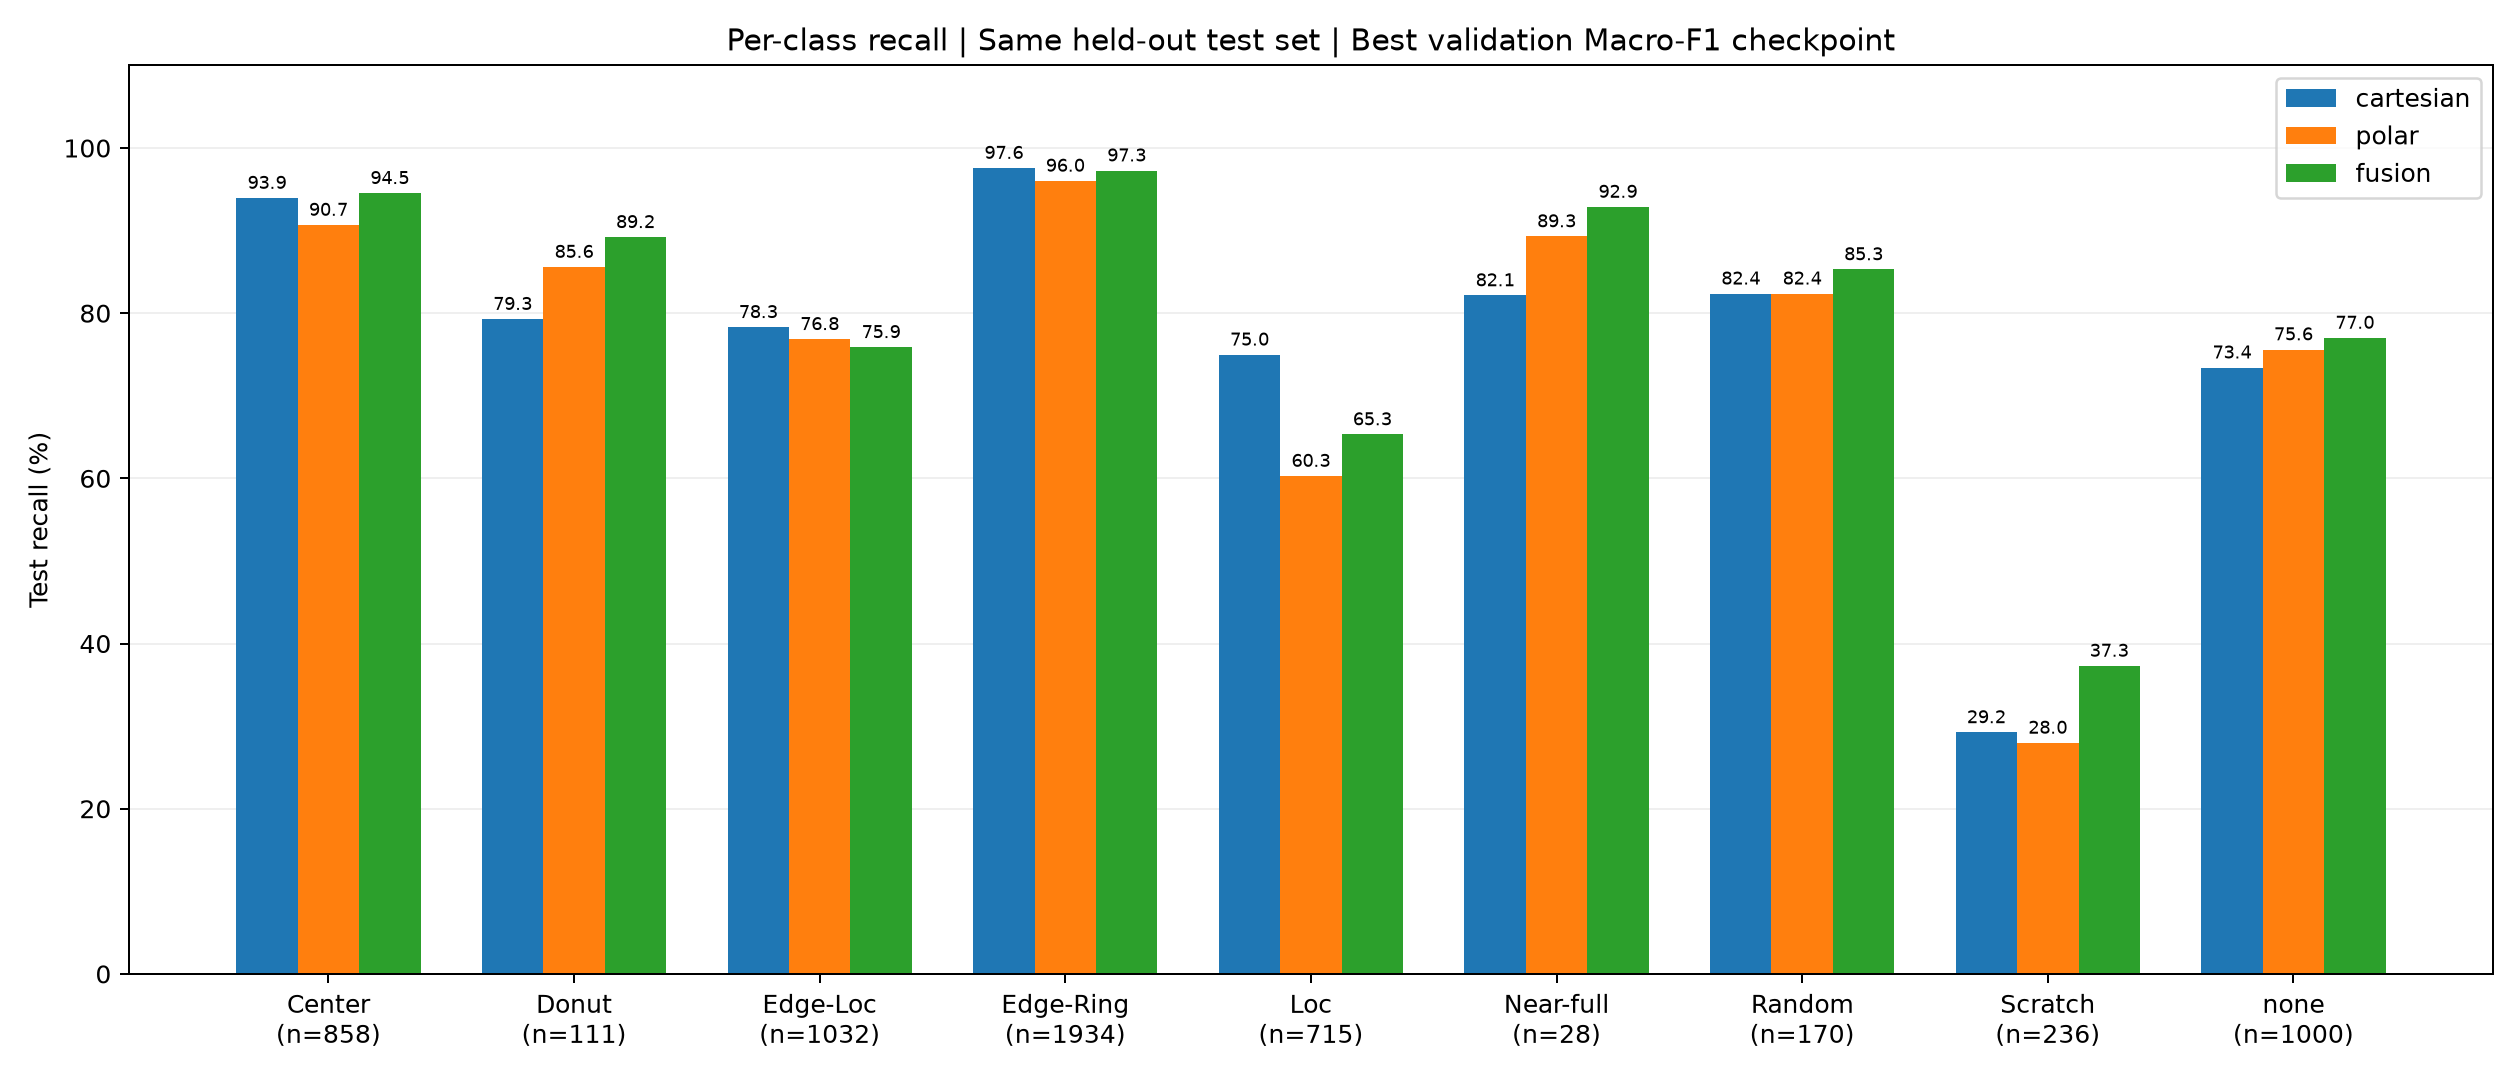

In [ ]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd
import subprocess, sys
ROOT = Path.cwd()
assert (ROOT / "run_experiment.py").exists(), "wafer-cnn 폴더에서 실행하세요."
OUTPUT = ROOT / "results" / "polar_comparison"


## 학습 실행
이미 실행 완료된 결과가 있으면 재학습하지 않습니다. 새 실험은 OUTPUT 경로를 변경하세요.


In [ ]:
if not (OUTPUT / "recall_comparison.png").exists():
    subprocess.run([sys.executable, "-u", str(ROOT / "run_experiment.py"), "--data", str(ROOT / "LSWMD.pkl"), "--output", str(OUTPUT)], check=True)


In [ ]:
display(pd.read_csv(OUTPUT / "summary.csv"))
display(pd.read_csv(OUTPUT / "recall_by_class.csv", index_col=0))
display(Image(filename=str(OUTPUT / "recall_comparison.png")))


In [ ]:
display(Image(filename=str(OUTPUT / "representations.png")))
